In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv('tpi_datos.csv')

In [5]:
df.head()

,Horas de consumo de redes sociales por día,Rendimieno académico
0,5,7
1,1,8
2,3,8
3,3,8
4,6,7


In [6]:
X_serie = df["Horas de  consumo de redes sociales por día"]
Y = df["Rendimieno académico"]

In [7]:
X = X_serie.values.reshape(-1, 1)

In [8]:
modelo = LinearRegression()
modelo.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.22]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.057
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[49.62]


In [9]:
intercept = modelo.intercept_
slope = modelo.coef_[0]

In [10]:
Y_pred = modelo.predict(X)
r_cuadrado = r2_score(Y, Y_pred) # Coeficiente de determinación

In [11]:
# En regresión simple, r es la raíz cuadrada de R², con el signo de la pendiente
r_value = np.sign(slope) * np.sqrt(r_cuadrado) 

print("RESULTADOS DE LA REGRESIÓN LINEAL (scikit-learn)")
print(f"c) Ecuación de la recta: Y = {intercept:.4f} + ({slope:.4f}) * X")
print(f"d) Pendiente (b): {slope:.4f}")
print(f"e) Coeficiente de correlación lineal (r): {r_value:.4f}")
print(f"f) Coeficiente de determinación (R²): {r_cuadrado:.4f}")

RESULTADOS DE LA REGRESIÓN LINEAL (scikit-learn)
c) Ecuación de la recta: Y = 8.0568 + (-0.2189) * X
d) Pendiente (b): -0.2189
e) Coeficiente de correlación lineal (r): -0.5831
f) Coeficiente de determinación (R²): 0.3400


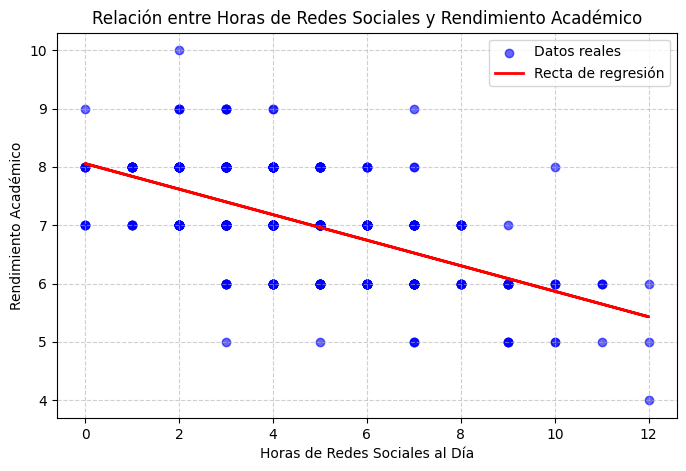

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color='blue', alpha=0.6, label='Datos reales')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Recta de regresión')

plt.title("Relación entre Horas de Redes Sociales y Rendimiento Académico")
plt.xlabel("Horas de Redes Sociales al Día")
plt.ylabel("Rendimiento Académico")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()